# Natural Disaster Tweet Classifier

## Purpose
Train and evaluate the natural disaster tweet classifier as consumption-zone evidence from exploitation tweet features.

## Inputs
`exploitation_analytics.fact_tweet_features` from the structured exploitation zone.

## Validation / quality checks
The notebook checks duplicates, missing values, retained training rows, train/test evaluation metrics, and selective rejection behavior.

## Transformation / cleaning logic
Tweet feature rows are filtered, encoded/vectorized for modelling, split into train/test sets, and evaluated with the configured classifier workflow.

## Metadata and lineage fields
Metrics evidence includes source assets, model name, accuracy, precision, recall, F1, created timestamp, schema version, and validation status.

## Output assets
`exploitation_analytics.model_tweet_classifier_metrics` and notebook model-evaluation evidence.

## RBAC / service user used
The production DAG uses ClickHouse consumption writer/reader roles for metrics writes and exploitation reads.

## Notebook-DAG alignment note
This notebook mirrors `consumption_zone_tweet_classifier`; it does not import DAG functions and preserves the same input/output semantics.


## Execution Notes and Batch Logging
This notebook is a consumption-zone model run: it loads one feature batch from ClickHouse, applies lightweight preprocessing, trains/evaluates a TF-IDF logistic-regression classifier, and writes model metrics back for evidence. The added print statements show the source batch size, train/test split, vectorization dimensions, evaluation size, and metrics write confirmation.


In this notebook, we develop a Natural Disaster Tweet Classifier. As the name suggests, this model takes a tweet as input and assigns one relevant disaster-related label to it, such as flood, earthquake, wildfire, cyclone or hurricane.

**Importing Useful Libraries**

In [1]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import clickhouse_connect
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import io
import os

# Load .env file
load_dotenv()

# Read environment variables
endpoint = os.getenv("MINIO_ENDPOINT")
MINIO_ROLE = "reader"
if MINIO_ROLE == "admin":
    access_key = os.getenv("MINIO_ACCESS_KEY")
    secret_key = os.getenv("MINIO_SECRET_KEY")
else:
    role_prefix = MINIO_ROLE.upper()
    access_key = os.getenv(f"MINIO_{role_prefix}_ACCESS_KEY")
    secret_key = os.getenv(f"MINIO_{role_prefix}_SECRET_KEY")
if not endpoint or not access_key or not secret_key:
    raise RuntimeError(f"Missing MinIO {MINIO_ROLE} credentials in environment")


In [2]:
# Create one reusable ClickHouse connection for the whole notebook.
clickhouse_user = os.getenv("CLICKHOUSE_CONSUMPTION_USER")
clickhouse_password = os.getenv("CLICKHOUSE_CONSUMPTION_PASSWORD")
if not clickhouse_user or not clickhouse_password:
    # NOTE: analytics is kept only as the local maintenance fallback.
    clickhouse_user = os.getenv("CLICKHOUSE_USER", "analytics")
    clickhouse_password = os.getenv("CLICKHOUSE_PASSWORD", "analytics_secret")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST", "clickhouse"),
    port=int(os.getenv("CLICKHOUSE_HTTP_PORT", "8123")),
    username=clickhouse_user,
    password=clickhouse_password,
)
print(f"Connected to ClickHouse host={os.getenv('CLICKHOUSE_HOST', 'clickhouse')} port={os.getenv('CLICKHOUSE_HTTP_PORT', '8123')} user={clickhouse_user}")


Connected to ClickHouse host=clickhouse port=8123 user=consumption_service


We load the fact_tweet_features table from ClickHouse, as it contains all the relevant features required to train the classifier.

In [3]:
# Get all rows of the table fact_tweet_features from ClickHouse
query = """
SELECT *
FROM exploitation_analytics.fact_tweet_features
"""

print("Loading batch 1/1: exploitation_analytics.fact_tweet_features")
df = client.query_df(query)
print(f"Loaded classifier feature batch: rows={len(df):,}, columns={len(df.columns)}")

Loading batch 1/1: exploitation_analytics.fact_tweet_features
Loaded classifier feature batch: rows=107,593, columns=21


**Exploratory Data Analysis**

The data contains 16 variables in total: 4 categorical variables and 12 numerical variables.

- **tweet_id**: unique identifier of the tweet  
- **disaster_type_key**: encoded key representing the disaster category  
- **disaster_type**: target label indicating the type of disaster (e.g., wildfire, flood, earthquake)
- **emoji_count**: number of emojis in the tweet  
- **tweet_text**: raw text content of the tweet  
- **text_length**: number of characters in the tweet  
- **word_count**: number of words in the tweet  
- **hashtag_count**: number of hashtags used  
- **mention_count**: number of user mentions  
- **url_count**: number of URLs included  
- **exclamation_count**: number of exclamation marks  
- **question_count**: number of question marks  
- **contains_youtube**: binary indicator for presence of YouTube mentions 
- **contains_alert_keyword**: binary indicator for alert-related keywords  
- **simple_sentiment_score**: numerical sentiment score of the tweet  
- **simple_sentiment_label**: categorical sentiment label (e.g., positive, neutral, negative)  

These features capture both structural and semantic properties of the tweets, providing a compact but informative representation for the classification task.

Duplicate rows: 0

=== Missing Values (%) ===
tweet_id                   0.0
disaster_type_key          0.0
disaster_type              0.0
emoji_count                0.0
tweet_text                 0.0
text_length                0.0
word_count                 0.0
hashtag_count              0.0
mention_count              0.0
url_count                  0.0
exclamation_count          0.0
question_count             0.0
contains_youtube           0.0
contains_alert_keyword     0.0
simple_sentiment_score     0.0
simple_sentiment_label     0.0
source_system              0.0
source_assets              0.0
created_at                 0.0
schema_version             0.0
exploitation_asset_type    0.0
dtype: float64

=== Disaster Type Distribution (%) ===
disaster_type
hurricane     48.408354
earthquake    17.700966
flood         17.671224
wildfire      12.078853
cyclone        4.140604
Name: proportion, dtype: Float64

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107593 en

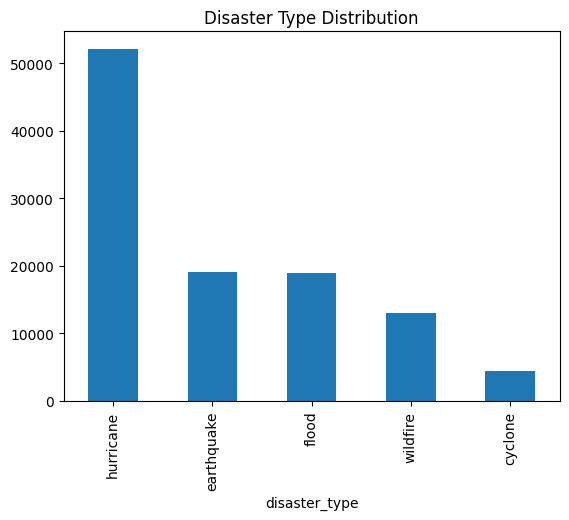

In [4]:
# 1. Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print()

# 2. Missing values
print("=== Missing Values (%) ===")
print((df.isnull().mean() * 100).sort_values(ascending=False))
print()

# 3. Label distribution
print("=== Disaster Type Distribution (%) ===")
print((df["disaster_type"].value_counts(normalize=True) * 100))
print()

# 4. Basic dataset info
print("=== Dataset Info ===")
print(df.info())
print()

# 5. Feature statistics
print("=== Numerical Feature Summary ===")
print(df.describe())
print()

# 6. Binary column sanity check
binary_cols = ["contains_youtube", "contains_alert_keyword"]
for col in binary_cols:
    print(f"{col} values:", df[col].value_counts().to_dict())

print()

# 7. Text sanity checks
print("Empty tweets:", (df["tweet_text"].str.strip() == "").sum())
print("Very short tweets (<5 chars):", (df["tweet_text"].str.len() < 5).sum())
print()

# 8. Label cleanup check
print("Unique disaster types:")
print(df["disaster_type"].unique())
print()

# 9. Quick visualization
plt.figure()
df["disaster_type"].value_counts().plot(kind="bar")
plt.title("Disaster Type Distribution")
plt.show()

There are also separate tables containing hashtags and emojis used in the tweets. In principle, these could have been incorporated as additional features to train the classifier and potentially improve performance. However, since the focus of this work is mainly on data management aspects, we keep the scope limited and only use the data available in the fact table.

Overall, the dataset is clean and well-structured, containing 127,527 records with no missing values or duplicate entries, which indicates strong data quality. The target variable, disaster_type, is moderately imbalanced: hurricanes (40.8%) and earthquakes (30.6%) dominate the distribution, while cyclone represents a small minority class (3.5%), which could introduce some bias toward the majority classes during training if not handled properly. Flood and wildfire fall in between these extremes. From a feature perspective, tweets are relatively short, averaging around 139 characters and 21 words, and they rarely contain URLs, mentions, or YouTube references, which suggests that the dataset is mostly composed of concise text-based messages. Sentiment scores are centered close to zero with a slight positive bias overall, while binary indicators such as contains_youtube and contains_alert_keyword are infrequent but still provide potentially useful signals. Overall, the dataset is clean, diverse in features, and suitable for building a multi-class disaster classification model.

Next, we preprocess the dataset and perform feature selection. For this task, we retain only the raw tweet text and the target variable disaster_type. Although additional engineered features (such as sentiment, counts, hashtags, and emojis) are available, they are ultimately derived from the original text and therefore do not introduce new independent information. The same reasoning applies to auxiliary tables containing hashtags and emojis, which can be seen as alternative representations of the text rather than additional signals. As a result, we deliberately focus on a text-only formulation of the problem to keep the modeling approach simple and aligned with the scope of the project.

**Preprocessing**

In [5]:
# Create a copy of the original dataframe
df_clean = df.copy()

# Remove very short, meaningless tweets
df_clean = df_clean[df_clean["word_count"] > 3]

print(f"Rows before preprocessing: {len(df):,}")
print(f"Rows after preprocessing: {len(df_clean):,}")
print(f"Filtered short-tweet rows: {len(df) - len(df_clean):,}")

Rows before preprocessing: 107,593
Rows after preprocessing: 107,182
Filtered short-tweet rows: 411


**Training**

In [6]:
# Final dataset
X = df_clean["tweet_text"]
y = df_clean["disaster_type"]

print(f"Training batch 1/3: splitting {len(df_clean):,} labelled tweets")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=2026
)
print(f"Training split complete: train={len(X_train):,}, test={len(X_test):,}")

print(f"Training batch 2/3: vectorizing text with TF-IDF")
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f"Vectorization complete: train_shape={X_train_vec.shape}, test_shape={X_test_vec.shape}")

print(f"Training batch 3/3: fitting LogisticRegression on {X_train_vec.shape[0]:,} rows and {X_train_vec.shape[1]:,} TF-IDF features")
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)
print("Model training completed.")

Training batch 1/3: splitting 107,182 labelled tweets
Training split complete: train=85,745, test=21,437
Training batch 2/3: vectorizing text with TF-IDF
Vectorization complete: train_shape=(85745, 20000), test_shape=(21437, 20000)
Training batch 3/3: fitting LogisticRegression on 85,745 rows and 20,000 TF-IDF features
Model training completed.


**Consumption Metrics Output**

This cell mirrors the production DAG output contract for `consumption_zone_tweet_classifier`: the model logic remains the same as the training cell above, and the added fields are lightweight consumption metadata.

In [7]:
# This metrics output mirrors src.consumption_zone.tweet_classifier.NaturalDisasterTweetClassifierPipeline.
print(f"Evaluation batch 1/2: predicting {X_test_vec.shape[0]:,} test rows")
y_pred = clf.predict(X_test_vec)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

created_at = os.getenv("AIRFLOW_LOGICAL_DATE") or os.getenv("CONSUMPTION_LOGICAL_DATE") or "notebook_manual"
classifier_metrics_record = {
    "row_count": int(len(df_clean)),
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "source_system": "exploitation_zone",
    "source_assets": "exploitation_analytics.fact_tweet_features",
    "created_at": created_at,
    "schema_version": "consumption_v1",
    "consumption_task": "natural_disaster_tweet_classifier",
    "model_name": "tfidf_logistic_regression",
    "model_version": "v1",
}

classifier_metrics_columns = [
    "row_count",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "train_size",
    "test_size",
    "source_system",
    "source_assets",
    "created_at",
    "schema_version",
    "consumption_task",
    "model_name",
    "model_version",
]

client.command("""
CREATE TABLE IF NOT EXISTS exploitation_analytics.model_tweet_classifier_metrics
(
    row_count UInt64,
    accuracy Float64,
    precision Float64,
    recall Float64,
    f1 Float64,
    train_size UInt64,
    test_size UInt64,
    source_system String,
    source_assets String,
    created_at String,
    schema_version String,
    consumption_task String,
    model_name String,
    model_version String
)
ENGINE = MergeTree()
ORDER BY (created_at, consumption_task, model_name, model_version)
""")
print("Evaluation batch 2/2: writing classifier metrics to exploitation_analytics.model_tweet_classifier_metrics")
client.insert(
    table="model_tweet_classifier_metrics",
    data=[[classifier_metrics_record[column] for column in classifier_metrics_columns]],
    column_names=classifier_metrics_columns,
    database="exploitation_analytics",
)
print(f"Classifier metrics written: accuracy={classifier_metrics_record['accuracy']:.4f}, f1={classifier_metrics_record['f1']:.4f}")

classifier_metrics_record


Evaluation batch 1/2: predicting 21,437 test rows
Evaluation batch 2/2: writing classifier metrics to exploitation_analytics.model_tweet_classifier_metrics
Classifier metrics written: accuracy=0.9680, f1=0.9680


{'row_count': 107182,
 'accuracy': 0.9680459019452349,
 'precision': 0.9687122524853365,
 'recall': 0.9680459019452349,
 'f1': 0.9679828093469973,
 'train_size': 85745,
 'test_size': 21437,
 'source_system': 'exploitation_zone',
 'source_assets': 'exploitation_analytics.fact_tweet_features',
 'created_at': 'notebook_manual',
 'schema_version': 'consumption_v1',
 'consumption_task': 'natural_disaster_tweet_classifier',
 'model_name': 'tfidf_logistic_regression',
 'model_version': 'v1'}

**Prediction with Rejection**

To handle out-of-distribution inputs such as irrelevant or non-disaster-related tweets, the model is extended with a rejection mechanism based on prediction confidence. If the maximum class probability falls below a predefined threshold, the system abstains from making a prediction and assigns the label "unknown". This allows the classifier to avoid overconfident predictions on inputs that do not resemble any training distribution.

In [8]:
def predict_with_rejection(texts, threshold=0.6):
    print(f"Prediction request batch: texts={len(texts)}, threshold={threshold}")
    X_vec = vectorizer.transform(texts)
    
    probs = clf.predict_proba(X_vec)
    max_probs = probs.max(axis=1)
    preds = clf.classes_[np.argmax(probs, axis=1)]
    
    final_preds = [
        pred if p >= threshold else "unknown"
        for pred, p in zip(preds, max_probs)
    ]
    
    return final_preds, max_probs

In [9]:
# Sample inputs
samples = [
    "Massive earthquake hits California",
    "hello world",
    "wildfire spreading rapidly near forest"
]

preds, confs = predict_with_rejection(samples, threshold=0.6)

list(zip(samples, preds, confs))

Prediction request batch: texts=3, threshold=0.6


[('Massive earthquake hits California',
  'earthquake',
  np.float64(0.7842826722954724)),
 ('hello world', 'unknown', np.float64(0.560171471302506)),
 ('wildfire spreading rapidly near forest',
  'wildfire',
  np.float64(0.981251774871449))]

The results show the behaviour of the selective classification mechanism.

For clearly disaster-related inputs (e.g., "Massive earthquake hits California" and "wildfire spreading rapidly near forest"), the model assigns the correct class with high confidence scores (0.78 and 0.99 respectively), indicating strong alignment between the input text and learned patterns.

In contrast, for a non-disaster or out-of-context input such as "hello world", the model produces a relatively low confidence score (0.46), which falls below the rejection threshold. As a result, the prediction is assigned to the "unknown" class.

This demonstrates that the confidence-based rejection mechanism is effective in filtering ambiguous or irrelevant inputs while preserving accurate classification for meaningful disaster-related tweets.